In [374]:
import numpy as np
import matplotlib.pyplot as plt


In [375]:

from pathlib import Path

PROJECT_ROOT = Path('/Users/tsouros/Desktop/Projects/STL-Dev')
DATA_DIR = PROJECT_ROOT / 'data/test'
SCATTERING_DIR = PROJECT_ROOT / 'scattering_vi'
COVARIANCE_DIR = SCATTERING_DIR / 'covariances'

TURB6_PATH = DATA_DIR / 'Turb_6.npy'
CIB_PATH = DATA_DIR / 'cib.npy'
TEST_DATA_PATH = DATA_DIR / 'mock_data.npy'
POSTERIOR_PATH = SCATTERING_DIR / 'mock_data_initialized_cib_likelihood_posterior.npz'
# POSTERIOR_PATH = SCATTERING_DIR / 'samples.npz'
COV_NPZ = COVARIANCE_DIR / '100_Herschel_Lockman_250m_tiles_3400x256x256_covariance.npz'
COV_JSON = COVARIANCE_DIR / '100_Herschel_Lockman_250m_tiles_3400x256x256_covariance.json'

s_stack = np.load(TURB6_PATH)
s_raw = np.asarray(s_stack[0], dtype=float)
s = s_raw - s_raw.mean()
n = np.load(CIB_PATH)

observed_data = np.load(TEST_DATA_PATH)
if observed_data.ndim == 3:
    observed_data = observed_data[0]

post = np.load(POSTERIOR_PATH, allow_pickle=True)


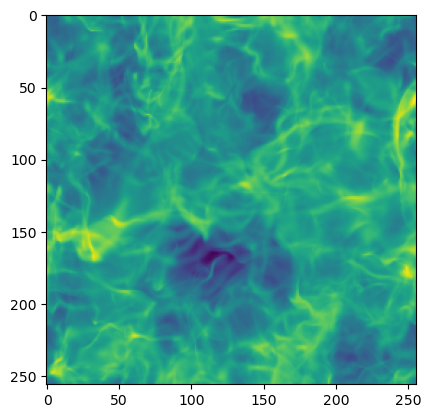

In [387]:
plt.imshow(np.fft.fftshift(s_raw))
# plt.imshow(s_raw)

In [377]:
# Loaded in setup cell above.

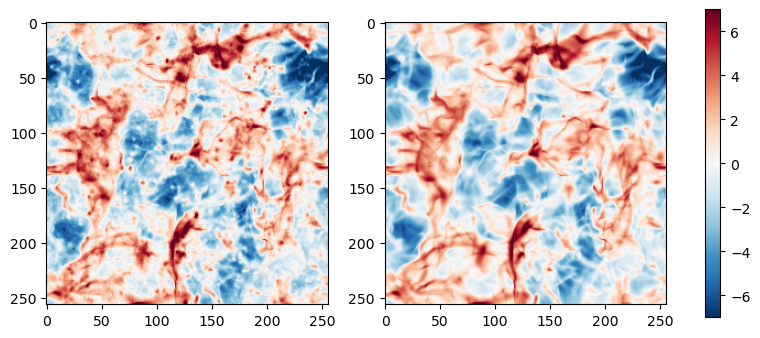

In [378]:
par = 10
a = par*s + n
a = a - np.mean(a)
b = par*s
b = b - np.mean(b)

# a = n
# a = a - np.mean(a)
# b = d - sample
# b = b - np.mean(b)

# vmax = max(np.abs(a).max(), np.abs(b).max())
vmax = 7
vmin = -vmax

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(a, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[1].imshow(b, cmap="RdBu_r", vmin=vmin, vmax=vmax)

fig.colorbar(im, ax=axes)
plt.show()

In [379]:
np.save('mock_data.npy', a)

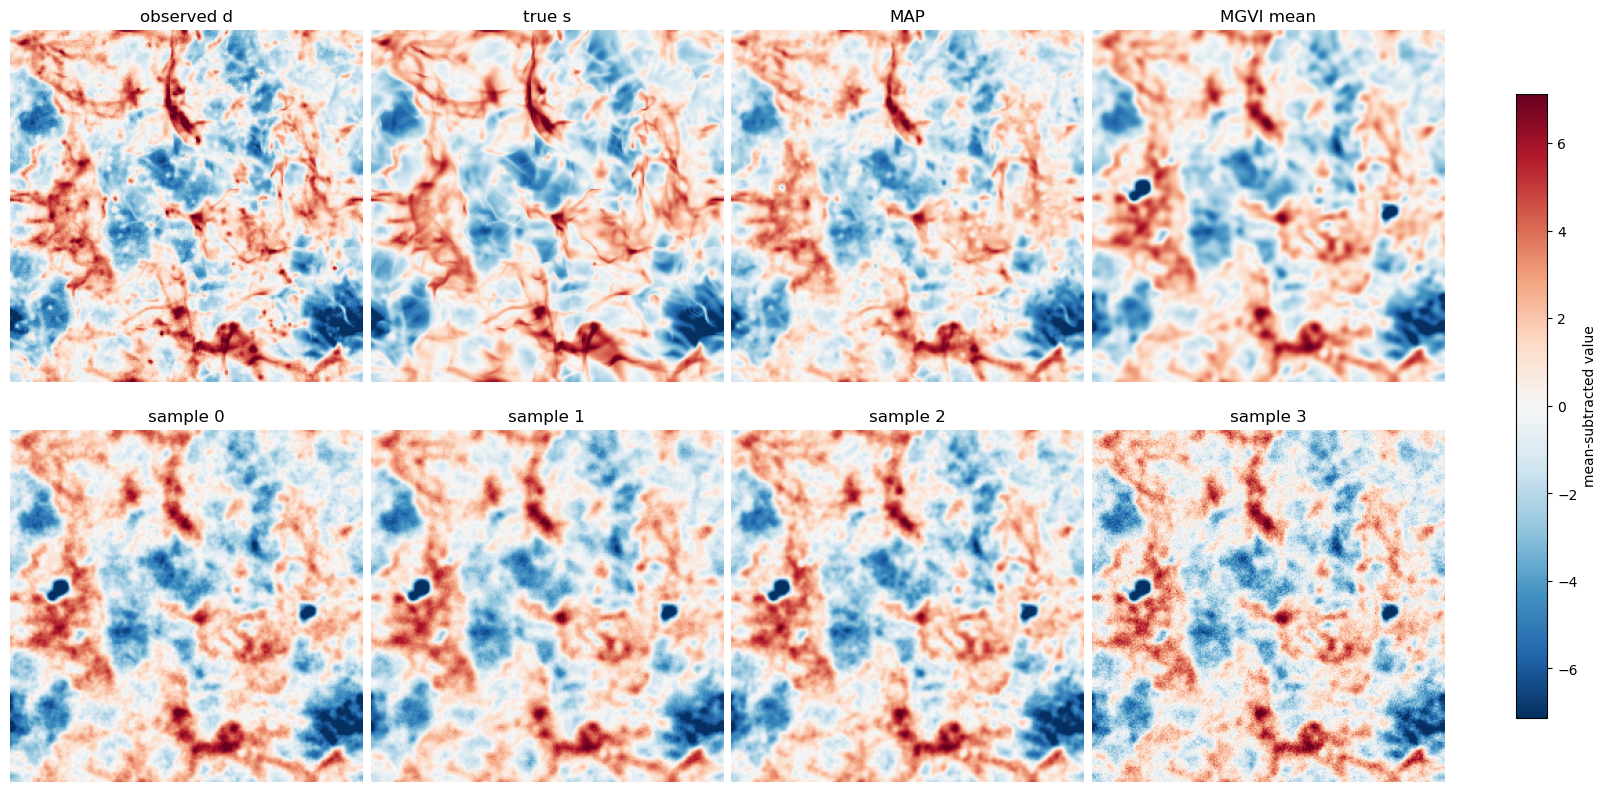

In [380]:

# Compare observed data, true signal, MAP/MGVI, and posterior samples on one color scale.
# Each image is mean-subtracted before plotting.

true_signal = observed_data - n

images = [
    ('observed d', observed_data),
    ('true s', true_signal),
]

if 'map_signal' in post.files and post['map_signal'].shape != ():
    images.append(('MAP', post['map_signal']))
if 'posterior_mean' in post.files and post['posterior_mean'].shape != ():
    images.append(('MGVI mean', post['posterior_mean']))

samples = post['posterior_samples'] if 'posterior_samples' in post.files else np.empty((0,))
if samples.ndim == 3:
    for i in range(min(4, samples.shape[0])):
        images.append((f'sample {i}', samples[i]))

centered = [(name, np.asarray(img, dtype=float) - np.nanmean(img)) for name, img in images]
scale = max(np.nanpercentile(np.abs(img), 99) for _, img in centered)

ncols = 4
nrows = int(np.ceil(len(centered) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 4*nrows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

im = None
for ax, (name, img) in zip(axes, centered):
    im = ax.imshow(img, origin='lower', cmap='RdBu_r', vmin=-scale, vmax=scale)
    ax.set_title(name)
    ax.axis('off')
for ax in axes[len(centered):]:
    ax.axis('off')

fig.colorbar(im, ax=axes[:len(centered)], shrink=0.8, label='mean-subtracted value')
plt.show()


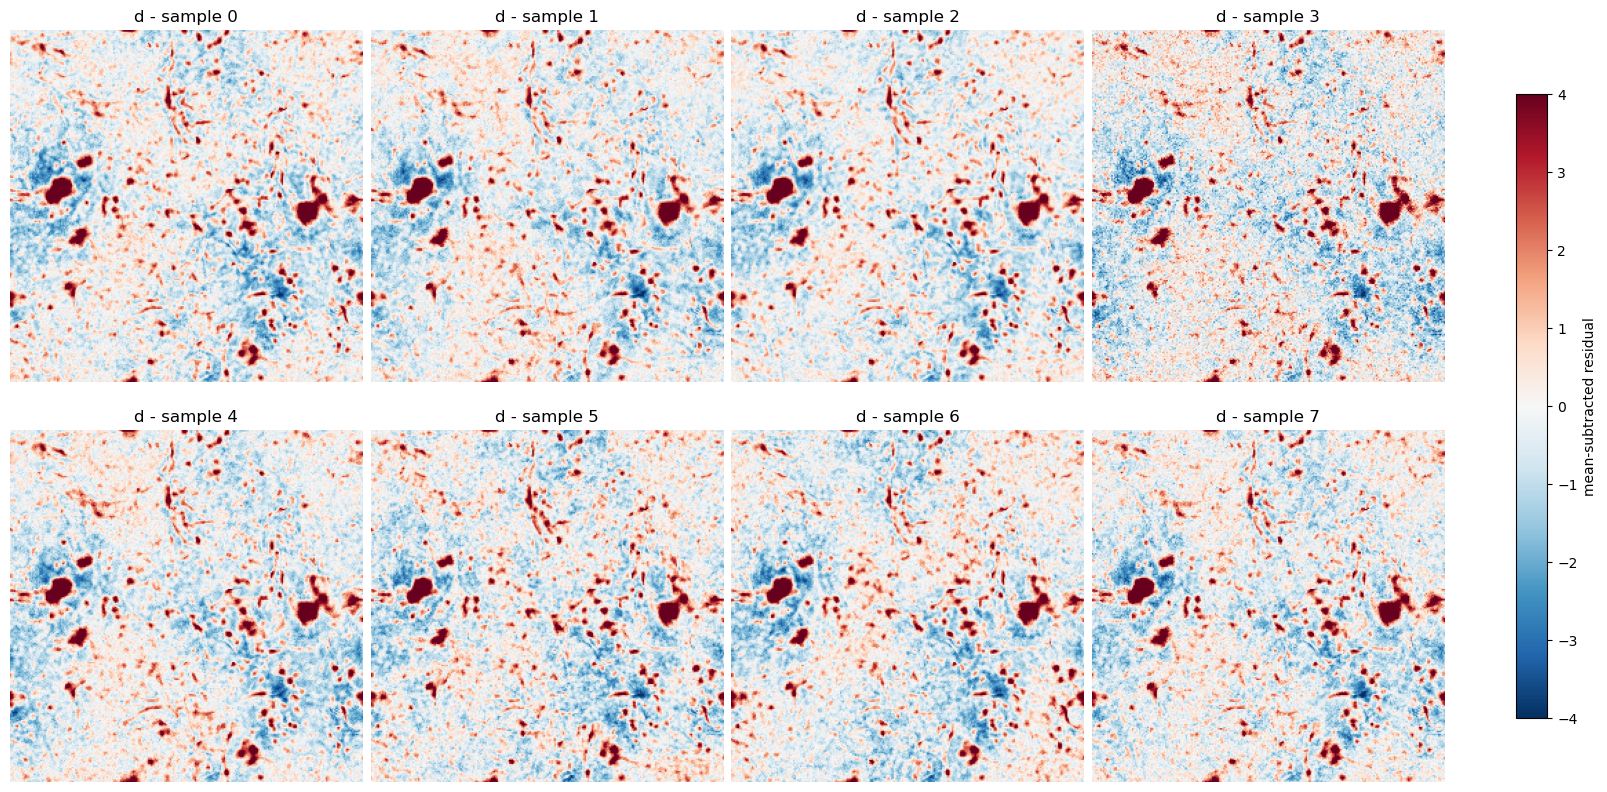

In [381]:

# Plot residual noise fields n = d - s_sample only.
# Every panel is mean-subtracted before plotting. Layout: 2 rows x 4 columns.

samples = post['posterior_samples']
if samples.ndim != 3 or samples.shape[0] == 0:
    raise ValueError('No posterior samples found in posterior_samples')

n_show = min(8, samples.shape[0])
images = []
for i in range(n_show):
    implied_noise = observed_data - samples[i]
    images.append((f'd - sample {i}', implied_noise))

centered = [(name, np.asarray(img, dtype=float) - np.nanmean(img)) for name, img in images]
scale = max(np.nanpercentile(np.abs(img), 99) for _, img in centered)

fig, axes = plt.subplots(2, 4, figsize=(16, 8), constrained_layout=True)
axes = axes.ravel()

im = None
for ax, (name, img) in zip(axes, centered):
    im = ax.imshow(img, origin='lower', cmap='RdBu_r', vmin=-4, vmax=4)
    ax.set_title(name)
    ax.axis('off')
for ax in axes[len(centered):]:
    ax.axis('off')

fig.colorbar(im, ax=axes[:len(centered)], shrink=0.8, label='mean-subtracted residual')
plt.show()


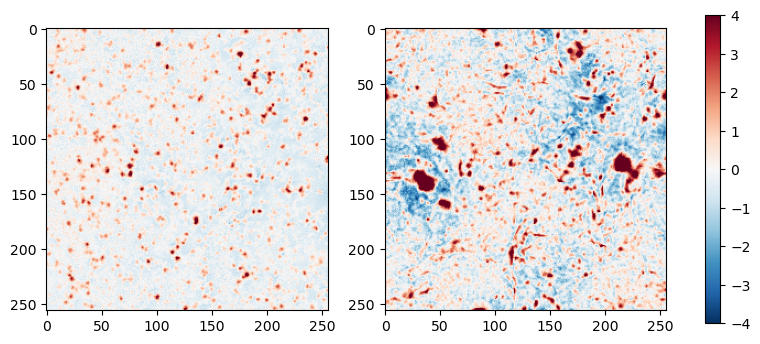

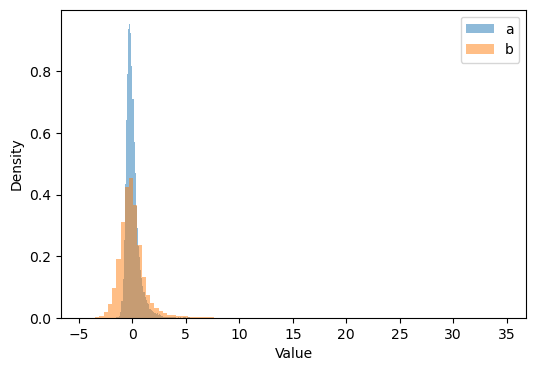

In [382]:
a = n
a = a - np.mean(a)
b = observed_data - samples[0]
b = b - np.mean(b)

vmax = 4
vmin = -4

# Maps
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

im = axes[0].imshow(a, cmap="RdBu_r", vmin=vmin, vmax=vmax)
axes[1].imshow(b, cmap="RdBu_r", vmin=vmin, vmax=vmax)

fig.colorbar(im, ax=axes)
plt.show()

# Superimposed histograms
plt.figure(figsize=(6, 4))

plt.hist(a.ravel(), bins=100, alpha=0.5, label="a", density=True)
plt.hist(b.ravel(), bins=100, alpha=0.5, label="b", density=True)

plt.legend()
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

active statistic dimension d = 188
expected Gaussian-null rho ~ sqrt(d) = 13.711
MAP residual             rho^2=121.502  rho=11.023
MGVI mean residual       rho^2=550.019  rho=23.452
sample 0 residual        rho^2=368.520  rho=19.197
sample 1 residual        rho^2=260.413  rho=16.137
sample 2 residual        rho^2=419.598  rho=20.484
sample 3 residual        rho^2=770.362  rho=27.755
sample 4 residual        rho^2=265.719  rho=16.301
sample 5 residual        rho^2=338.902  rho=18.409
sample 6 residual        rho^2=300.404  rho=17.332
sample 7 residual        rho^2=211.466  rho=14.542


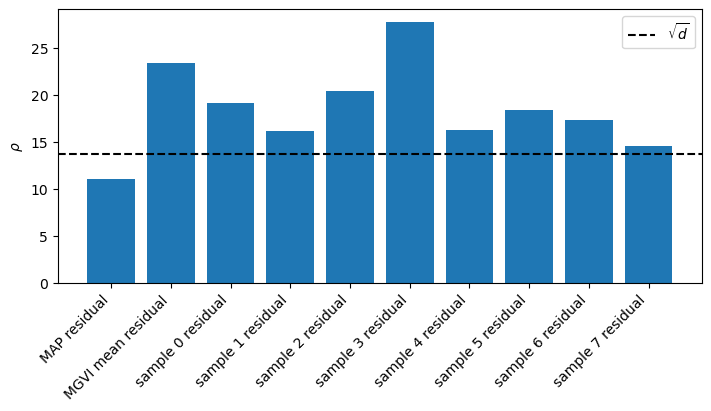

In [383]:

# Residual likelihood diagnostic using the learned CIB scattering Gaussian.
# Standalone: does not use NIFTy/microsample.py.
# For each reconstruction s_hat, compute n_hat = d - s_hat and
# rho^2 = (phi(n_hat)-mu)^T C^{-1} (phi(n_hat)-mu).

import sys
import json
import inspect
from pathlib import Path
import torch

PROJECT_DIR = SCATTERING_DIR
STL_ROOT = PROJECT_ROOT
if str(STL_ROOT) not in sys.path:
    sys.path.insert(0, str(STL_ROOT))

import STL_main.torch_backend as bk
from STL_main.STL_2D_FFT_Torch import STL_2D_FFT_Torch as DataClass

cov_npz = COV_NPZ
cov_json = COV_JSON
posterior_path = POSTERIOR_PATH
data_path = TEST_DATA_PATH

def torch_dtype(name):
    return {'float32': torch.float32, 'float64': torch.float64}[name]

def configure_backend(device, dtype):
    if hasattr(bk, 'set_default_device'):
        bk.set_default_device(device)
    else:
        bk._DEFAULT_DEVICE = device
    bk._DEFAULT_DTYPE = dtype
    bk._DEFAULT_COMPLEX_DTYPE = torch.complex64 if dtype == torch.float32 else torch.complex128

def apply_st_operator(st_op, data, **kwargs):
    sig = inspect.signature(st_op.apply)
    if any(p.kind == inspect.Parameter.VAR_KEYWORD for p in sig.parameters.values()):
        return st_op.apply(data, **kwargs)
    supported = {k: v for k, v in kwargs.items() if k in sig.parameters}
    return st_op.apply(data, **supported)

def build_st_operator(data, cfg):
    return data.get_ST_op(
        J=cfg['J'],
        L=cfg['L'],
        WType=cfg.get('wtype', 'Bump-Steerable'),
        iso=cfg['iso'],
        angular_ft=cfg['angular_ft'],
        harmonics_angle=cfg['harmonics_angle'],
        scale_ft=cfg['scale_ft'],
        harmonics_scale=cfg['harmonics_scale'],
        dj=cfg['dj'],
        compute_PS=cfg['compute_ps'],
        has_fewer_convolutions=cfg.get('fewer_convolutions', False),
    )

def scattering_vector(x2d, st_op, cfg):
    x = torch.as_tensor(x2d, device=device, dtype=dtype)
    data = DataClass(x[None, None, :, :], pbc=cfg['pbc'])
    standardized, _, _ = st_op.wavelet_op.standardize(data, mean_field=False, inplace=False)
    stats = apply_st_operator(
        st_op,
        standardized,
        norm='load_ref',
        compute_PS=cfg['compute_ps'],
    )
    return stats.to_flatten(
        keep_batch_dim=True,
        mean_along_batch=False,
        keepnans=False,
        flatten_complex=True,
    ).real[0]

with open(cov_json, 'r') as f:
    metadata = json.load(f)
cfg = metadata['config']

cov = np.load(cov_npz)
d = observed_data

mu = cov['mean']
C = cov['covariance']
active = cov['active_statistic_mask'] if 'active_statistic_mask' in cov.files else np.ones(mu.shape, dtype=bool)
mu = mu[active]
C = C[np.ix_(active, active)]
C = 0.5 * (C + C.T)
precision = np.linalg.pinv(C)

device = torch.device('cpu')
dtype = torch_dtype(cfg.get('dtype', 'float64'))
configure_backend(device, dtype)

example = DataClass(torch.zeros((1, 1, cfg['target_size'], cfg['target_size']), device=device, dtype=dtype), pbc=cfg['pbc'])
st_op = build_st_operator(example, cfg)

# Load the STL normalization/reference state saved with the covariance product.
ref_map = {
    'S2_ref_sqrt_chan_diag': 'stl_reference_S2_ref_sqrt_chan_diag',
    'var_ref': 'stl_reference_var_ref',
    'PS_ref_sqrt_chan_diag': 'stl_reference_PS_ref_sqrt_chan_diag',
}
for attr, key in ref_map.items():
    if key in cov.files and cov[key].size:
        setattr(st_op, attr, torch.as_tensor(cov[key], device=device, dtype=dtype))

precision_t = torch.as_tensor(precision, device=device, dtype=dtype)
mu_t = torch.as_tensor(mu, device=device, dtype=dtype)
active_t = torch.as_tensor(active, device=device, dtype=torch.bool)

def rho2_for_noise(noise_map):
    with torch.no_grad():
        phi = scattering_vector(noise_map, st_op, cfg)[active_t]
        diff = phi - mu_t
        return float(diff @ (precision_t @ diff))

items = []
if 'map_signal' in post.files and post['map_signal'].shape != ():
    items.append(('MAP residual', d - post['map_signal']))
if 'posterior_mean' in post.files and post['posterior_mean'].shape != ():
    items.append(('MGVI mean residual', d - post['posterior_mean']))
if 'posterior_samples' in post.files:
    samples = post['posterior_samples']
    for i in range(min(8, samples.shape[0])):
        items.append((f'sample {i} residual', d - samples[i]))

names = []
rho2_values = []
for name, residual in items:
    names.append(name)
    rho2_values.append(rho2_for_noise(residual))

rho2_values = np.asarray(rho2_values)
rho_values = np.sqrt(rho2_values)
d_active = int(active.sum())
expected_rho = np.sqrt(d_active)

print(f'active statistic dimension d = {d_active}')
print(f'expected Gaussian-null rho ~ sqrt(d) = {expected_rho:.3f}')
for name, r2, r in zip(names, rho2_values, rho_values):
    print(f'{name:24s} rho^2={r2:.3f}  rho={r:.3f}')

fig, ax = plt.subplots(figsize=(max(7, 0.45*len(names)), 4), constrained_layout=True)
ax.bar(np.arange(len(names)), rho_values)
ax.axhline(expected_rho, color='k', ls='--', label=r'$\sqrt{d}$')
ax.set_xticks(np.arange(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel(r'$\rho$')
ax.legend()
plt.show()


field std of 10*s: 2.53272
power spectrum slope: -3.07751
amplitude spectrum slope: -1.53876
amplitude prefactor in fitted units: 0.0832014

Suggested NIFTy prior settings:
--prior-loglog-slope-mean -1.53876
--prior-loglog-slope-std 0.3
--prior-fluctuations-mean 2.53272
--prior-fluctuations-std 1.26636


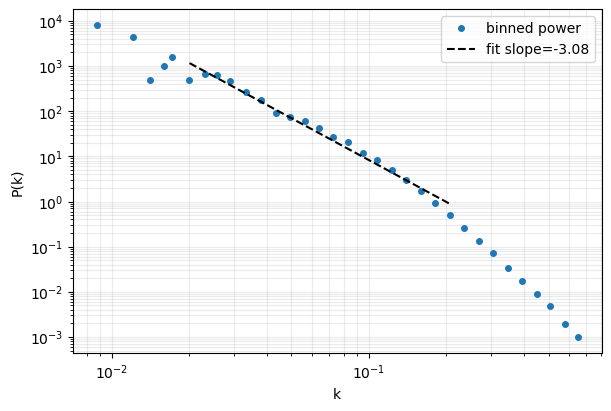

In [384]:

# Estimate isotropic power-spectrum parameters for 10*s.
# This gives a data-driven setting for the Gaussian correlated-field prior.

s0 = np.asarray(s_raw, dtype=float)
x = 10.0 * s0
x = x - np.mean(x)

ny, nx = x.shape
kx = np.fft.fftfreq(nx)
ky = np.fft.fftfreq(ny)
KX, KY = np.meshgrid(kx, ky)
k = np.sqrt(KX**2 + KY**2)

ft = np.fft.fft2(x, norm='ortho')
ps2d = np.abs(ft)**2

# Radial binning. Ignore k=0 and very high-k edge modes.
k_flat = k.ravel()
ps_flat = ps2d.ravel()
mask = k_flat > 0
k_flat = k_flat[mask]
ps_flat = ps_flat[mask]

nbins = 40
bins = np.geomspace(k_flat.min(), k_flat.max(), nbins + 1)
k_bin = []
ps_bin = []
for lo, hi in zip(bins[:-1], bins[1:]):
    m = (k_flat >= lo) & (k_flat < hi)
    if np.count_nonzero(m) >= 8:
        k_bin.append(np.exp(np.mean(np.log(k_flat[m]))))
        ps_bin.append(np.mean(ps_flat[m]))
k_bin = np.asarray(k_bin)
ps_bin = np.asarray(ps_bin)

# Fit only an intermediate range to avoid box-size and pixel-scale artifacts.
fit_mask = (
    (k_bin > np.percentile(k_bin, 15))
    & (k_bin < np.percentile(k_bin, 75))
    & np.isfinite(ps_bin)
    & (ps_bin > 0)
)
logk = np.log(k_bin[fit_mask])
logp = np.log(ps_bin[fit_mask])
power_slope, log_power_amp = np.polyfit(logk, logp, 1)
amp_slope = 0.5 * power_slope
amp_at_k0 = np.exp(0.5 * log_power_amp)
field_std = float(np.std(x))

print(f'field std of 10*s: {field_std:.6g}')
print(f'power spectrum slope: {power_slope:.6g}')
print(f'amplitude spectrum slope: {amp_slope:.6g}')
print(f'amplitude prefactor in fitted units: {amp_at_k0:.6g}')
print('\nSuggested NIFTy prior settings:')
print(f'--prior-loglog-slope-mean {amp_slope:.6g}')
print('--prior-loglog-slope-std 0.3')
print(f'--prior-fluctuations-mean {field_std:.6g}')
print(f'--prior-fluctuations-std {0.5*field_std:.6g}')

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
ax.loglog(k_bin, ps_bin, 'o', ms=4, label='binned power')
ax.loglog(k_bin[fit_mask], np.exp(log_power_amp) * k_bin[fit_mask]**power_slope, 'k--', label=f'fit slope={power_slope:.2f}')
ax.set_xlabel('k')
ax.set_ylabel('P(k)')
ax.legend()
ax.grid(True, which='both', alpha=0.25)
plt.show()
